In [1]:
import jax.numpy as jnp
import jax 
from jax.scipy.stats import norm
import matplotlib.pyplot as plt

def model(x0, theta, key, t_range):
    mu,rho,sigma = theta

    def step(state, i):
        prev_x, prev_key = state

        update_key, next_key = jax.random.split(prev_key, 2)

        x = (mu + rho * (prev_x - mu)) + sigma * jax.random.normal(update_key)

        return (x, next_key), x

    _,loop_val = jax.lax.scan(
        step,
        init=(x0, key),
        xs=t_range[1:],
    )

    return jnp.concatenate((x0[jnp.newaxis,:],loop_val))

In [2]:
def likelihood(particles, observation, par):
    return norm.logpdf(observation, loc=0, scale=jnp.exp(particles))

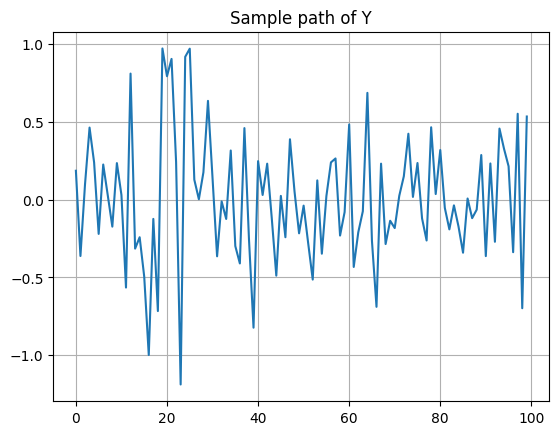

In [3]:
theta = (-1.,0.9,0.1)
t_range = jnp.arange(0,100,1)
rng_key = jax.random.key(5)

rng_key,init_key = jax.random.split(rng_key)

x0 = theta[0] + (theta[2]/jnp.sqrt(1. - theta[1]**2)) * jax.random.normal(init_key, shape=(1,))

rng_key,model_key = jax.random.split(rng_key)
xs = model(x0,theta,model_key,t_range)

rng_key,obs_key = jax.random.split(rng_key)
observations = jnp.exp(xs) * jax.random.normal(obs_key,shape = xs.shape)

plt.title('Sample path of Y')
plt.grid()
plt.plot(t_range,observations)
plt.show()

Iteration: 0 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 1 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 2 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 3 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 4 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 5 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 6 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 7 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 8 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 9 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 10 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 11 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 12 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 13 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 14 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 15 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 16 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 17 w/ [-0.37631533  0.9674947   0.8567683 ]
Iteration: 18 w/ [-0

/tmp/ipykernel_3276336/2001620892.py:76: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(samples[:, :, i], 40)
/home/avery/GradientBasedSamplers/.venv/lib/python3.12/site-packages/seaborn/distributions.py:2496: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


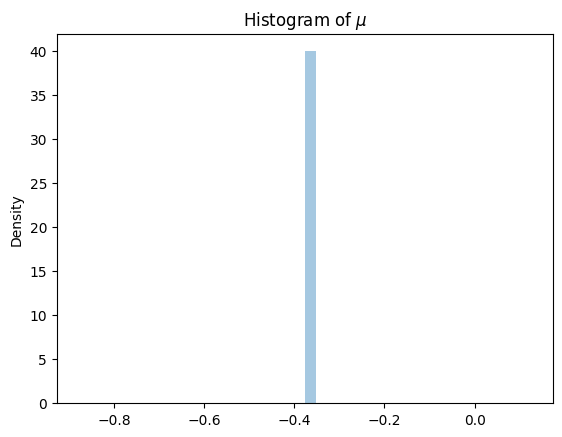

/tmp/ipykernel_3276336/2001620892.py:76: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(samples[:, :, i], 40)
/home/avery/GradientBasedSamplers/.venv/lib/python3.12/site-packages/seaborn/distributions.py:2496: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


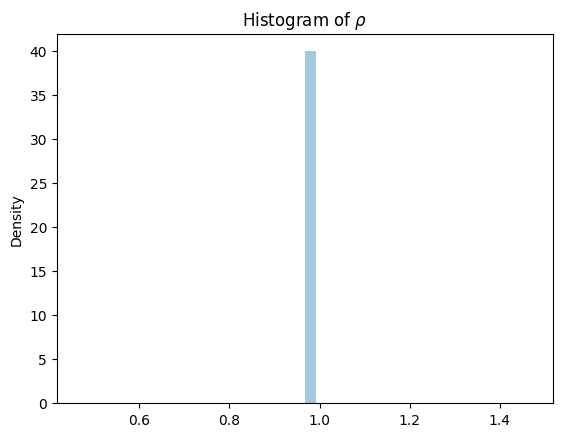

/tmp/ipykernel_3276336/2001620892.py:76: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sb.distplot(samples[:, :, i], 40)
/home/avery/GradientBasedSamplers/.venv/lib/python3.12/site-packages/seaborn/distributions.py:2496: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


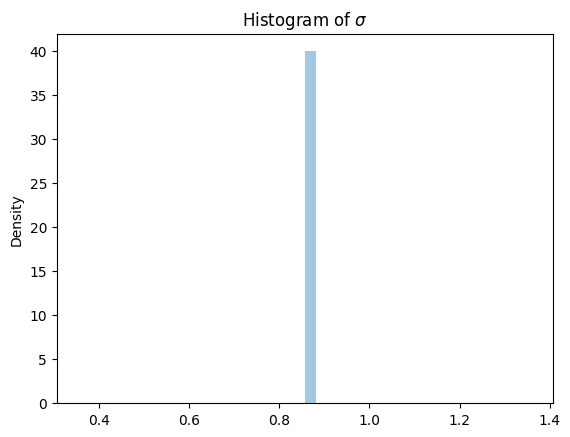

In [4]:
from algorithms.smc import particle_filter
from algorithms.mcmc import mcmc, multi_chain_mcmc
from jax.scipy.stats import norm, gamma, beta
import seaborn as sb

from utilities.helpers import (
    autocorrelation,
    auto_window,
    autocorr_new,
    effective_sample_size,
)


def f(theta, key, observations):
    num_particles = 50
    key, init_key = jax.random.split(key)
    particles = (theta[2] / jnp.sqrt(1.0 - theta[1] ** 2)) * jax.random.normal(
        init_key, shape=(num_particles, 1)
    )

    particles, weights = particle_filter(
        model,
        observations,
        particles,
        key,
        likelihood,
        theta,
        jnp.linspace(0, 1, 2),
    )

    return jnp.sum(jnp.log(jnp.mean(weights, axis=0)))


def log_p(theta, key):
    mu, rho, sigma = theta
    return (
        f(theta, key, observations)
        + norm.logpdf(mu)
        + beta.logpdf(rho, a=9.0, b=1.0)
        + gamma.logpdf(sigma, a=1)
    )


num_chains = 1
iterations = 1000
burnin = 100
pmmh_key, rng_key = jax.random.split(rng_key)

mu_key, sigma_key, rho_key, rng_key = jax.random.split(rng_key, 4)
theta0 = jnp.array(
    [
    jax.random.normal(mu_key),
    jax.random.beta(rho_key, a=9.0, b=1.0),
    jax.random.gamma(sigma_key, a=1),
    ]
).T

samples, lnprob = mcmc(
    f=log_p,
    M=iterations,
    burnin=burnin,
    theta0=theta0,
    adaptive=True,
    key=pmmh_key,
    cov_matrix=jnp.eye(len(theta)),
)

samples = samples[jnp.newaxis,...]

print(f"Effective sample size: {effective_sample_size(samples)}")
print(f"Integrated autocorrelation: {autocorr_new(samples)}")
theta_names = ["$\\mu$", "$\\rho$", "$\\sigma$"]

for i, name in enumerate(theta_names):
    plt.title(f"Histogram of {name}")
    sb.distplot(samples[:, :, i], 40)
    plt.show()